# 🎨 Artwork Similarity using Metric Learning

Understanding visual similarity in artworks is a challenging problem due to variations in style, composition, and artistic intent. Traditional classification approaches struggle to capture these nuanced relationships.

In this project, we build an image retrieval system for paintings using **metric learning**. Instead of predicting labels directly, the model learns a feature embedding space where visually or stylistically similar artworks are positioned closer together.

We train a ResNet-based model using **Triplet Loss** to learn artist-aware representations and evaluate it using similarity-based metrics such as Top-K accuracy and Precision@K.

To benchmark performance, we compare our model with **CLIP**, a large-scale pretrained vision-language model, highlighting the differences between domain-specific learning and general-purpose representations.

In [1]:
import pandas as pd
import os
import requests
from tqdm import tqdm
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import random

## Dataset Preparation

We use artwork metadata and images, filtering only paintings with valid artist attribution.

- Total samples after filtering: ~4000
- Each image is linked to an artist (label)

We integrate metadata from objects.csv with image endpoints from published_images.csv to construct a clean dataset of paintings with valid IIIF image links.

In [2]:
objects = pd.read_csv("objects.csv", low_memory=False)
images = pd.read_csv("published_images.csv", low_memory=False)

# Clean column names
objects.columns = objects.columns.str.strip().str.lower()
images.columns = images.columns.str.strip().str.lower()

# Select correct columns
objects = objects[["objectid", "uuid", "title", "classification", "attribution"]]
images = images[["depictstmsobjectid", "iiifurl"]]

# Correct merge
df = objects.merge(
    images,
    left_on="objectid",
    right_on="depictstmsobjectid"
)

print("After merge:", len(df))

After merge: 127109


In [3]:
df = df[df["classification"].str.lower() == "painting"]
df = df[df["iiifurl"].notna()]
df = df[df["attribution"].notna()]

print("After filtering:", len(df))

df = df.sample(min(4000, len(df)), random_state=42).reset_index(drop=True)

print("Final dataset:", len(df))

After filtering: 4053
Final dataset: 4000


## Image Downloading

Images are downloaded using IIIF URLs and stored locally for efficient training.

In [4]:
df["image_url"] = df["iiifurl"] + "/full/!224,224/0/default.jpg"

In [5]:
print(df.columns)

Index(['objectid', 'uuid', 'title', 'classification', 'attribution',
       'depictstmsobjectid', 'iiifurl', 'image_url'],
      dtype='object')


In [6]:
print(df.iloc[0]["image_url"])

https://api.nga.gov/iiif/a7df9210-3411-4764-8ca6-67d2b2b97aa3/full/!224,224/0/default.jpg


In [7]:
import requests
from PIL import Image
from io import BytesIO

url = df.iloc[0]["image_url"]

response = requests.get(url, timeout=5)
img = Image.open(BytesIO(response.content)).convert("RGB")

print("✅ Image loaded")

✅ Image loaded


In [5]:
import os
import requests
from tqdm import tqdm

os.makedirs("images", exist_ok=True)

for i, row in tqdm(df.iterrows(), total=len(df)):
    path = f"images/{row['uuid']}.jpg"

    if os.path.exists(path):
        continue

    try:
        img = requests.get(row["image_url"], timeout=5).content
        with open(path, "wb") as f:
            f.write(img)
    except:
        pass

100%|████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 39063.11it/s]


In [8]:
import os
print("Downloaded images:", len(os.listdir("images")))

Downloaded images: 3987


In [9]:
print("After filtering:", len(df))
print("Downloaded:", len(os.listdir("images")))

After filtering: 4000
Downloaded: 3987


In [10]:
import os

df["img_path"] = df["uuid"].apply(lambda x: f"images/{x}.jpg")
df = df[df["img_path"].apply(os.path.exists)].reset_index(drop=True)

print("Final usable dataset:", len(df))

Final usable dataset: 4000


## Data Augmentation

We apply transformations such as resizing, flipping, and color jitter to improve generalization.

In [11]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2,0.2,0.2,0.1),
    transforms.ToTensor(),
])

## Triplet Sampling Strategy

We construct (anchor, positive, negative) samples:
- Anchor & Positive → same artist
- Negative → different artist

This enables metric learning using Triplet Loss.

In [12]:
from PIL import Image
from torch.utils.data import Dataset
import random

class TripletDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform
        self.groups = df.groupby("attribution")

        # keep only artists with multiple images
        self.valid_artists = [
            k for k, v in self.groups.groups.items() if len(v) > 1
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        anchor = self.df.iloc[idx]
        anchor_label = anchor["attribution"]

        if anchor_label not in self.valid_artists:
            return self.__getitem__(random.randint(0, len(self.df)-1))

        # positive sample
        positive = self.groups.get_group(anchor_label).sample(1).iloc[0]

        # negative sample
        negative_label = random.choice(self.valid_artists)
        while negative_label == anchor_label:
            negative_label = random.choice(self.valid_artists)
        negative = self.groups.get_group(negative_label).sample(1).iloc[0]

        def safe_load(row):
            try:
                return self.transform(Image.open(row["img_path"]).convert("RGB"))
            except:
                # retry with random valid sample
                new_row = self.df.sample(1).iloc[0]
                return safe_load(new_row)

        anchor_img = safe_load(anchor)
        positive_img = safe_load(positive)
        negative_img = safe_load(negative)

        return anchor_img, positive_img, negative_img

In [13]:
from torch.utils.data import DataLoader

dataset = TripletDataset(df, transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

## Model Architecture

We use a pretrained ResNet18 backbone and project features into a 256-dimensional embedding space.

Embeddings are L2-normalized.  
This ensures cosine similarity reflects angular distance between feature vectors.

We trained a ResNet18-based embedding model using triplet loss to learn visual similarity between artworks. The model maps images into a feature space where similar artworks are closer together.

In [14]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights
import torch.nn as nn
import torch.nn.functional as F

class EmbeddingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)
        self.backbone.fc = nn.Linear(512, 256)

    def forward(self, x):
        return F.normalize(self.backbone(x), dim=1)

## Training

The model is trained using Triplet Margin Loss.

Due to computational constraints, training was limited to a few epochs.

In [13]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = EmbeddingNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.TripletMarginLoss(margin=1.0)

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for anchor, positive, negative in loader:
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        a = model(anchor)
        p = model(positive)
        n = model(negative)

        loss = criterion(a, p, n)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 80.5742
Epoch 2, Loss: 28.8325
Epoch 3, Loss: 21.9782


In [14]:
best_loss = float("inf")

epochs = 5 

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for anchor, positive, negative in loader:
        # Move to device
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        # Forward pass
        a = model(anchor)
        p = model(positive)
        n = model(negative)

        # Compute loss
        loss = criterion(a, p, n)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss
        total_loss += loss.item()

    # Print epoch loss
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

    # Save best model
    if total_loss < best_loss:
        best_loss = total_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved")

Epoch 1/5, Loss: 23.1887
✅ Best model saved
Epoch 2/5, Loss: 27.5061
Epoch 3/5, Loss: 17.9586
✅ Best model saved
Epoch 4/5, Loss: 23.6937
Epoch 5/5, Loss: 32.0189


Due to computational constraints, training was limited to a small number of epochs. Increasing training duration and incorporating advanced sampling strategies such as hard negative mining could further improve performance.

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = EmbeddingNet().to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

EmbeddingNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [16]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## Embedding Extraction

After training, embeddings are extracted for all images and normalized.

In [20]:
from PIL import Image
import os
import numpy as np

embeddings = []

with torch.no_grad():
    for i in range(len(df)):
        try:
            img_path = f"images/{df.iloc[i]['uuid']}.jpg"

            if not os.path.exists(img_path):
                continue

            img = Image.open(img_path).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            emb = model(img).cpu().numpy()
            embeddings.append(emb)

        except Exception:
            continue

# stack embeddings
embeddings = np.vstack(embeddings)

embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

print("✅ Final embeddings:", embeddings.shape)

Error at 1659: cannot identify image file 'images/3878dcd6-9cdc-4ea6-983b-d8a53bb6f670.jpg'
✅ Final embeddings: (3998, 256)


## Image Retrieval

We compute cosine similarity between embeddings to retrieve visually similar artworks.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

def show_similar(idx, top_k=5):
    sim = cosine_similarity([embeddings[idx]], embeddings)[0]
    indices = sim.argsort()[-top_k-1:-1][::-1]

    fig, axes = plt.subplots(1, top_k+1, figsize=(15,5))

    axes[0].imshow(Image.open(df.iloc[idx]["img_path"]))
    axes[0].set_title("Query")
    axes[0].axis("off")

    for i, ind in enumerate(indices):
        axes[i+1].imshow(Image.open(df.iloc[ind]["img_path"]))
        axes[i+1].axis("off")

    plt.show()

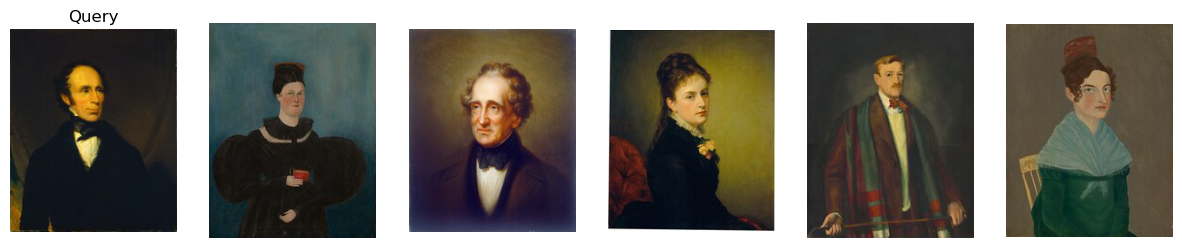

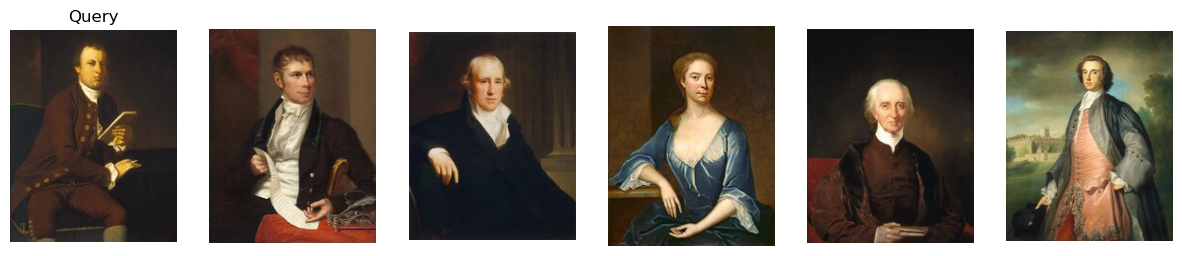

In [19]:
show_similar(10)
show_similar(100)

In [20]:
pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /private/var/folders/kg/5fqjl4753r94_x_wqspmvr580000gn/T/pip-req-build-l95e739t
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/kg/5fqjl4753r94_x_wqspmvr580000gn/T/pip-req-build-l95e739t
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [21]:
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [22]:
clip_embeddings = []

with torch.no_grad():
    for i in range(len(df)):
        try:
            img = preprocess(Image.open(df.iloc[i]["img_path"])).unsqueeze(0).to(device)
            emb = clip_model.encode_image(img).cpu().numpy()
            clip_embeddings.append(emb)
        except:
            clip_embeddings.append(None)

## Precision@K Evaluation

In [26]:
# Precision@K
def precision_at_k(idx, k=5):
    query_artist = df.iloc[idx]["attribution"]

    sim = cosine_similarity([embeddings[idx]], embeddings)[0]
    indices = sim.argsort()[-k-1:-1]

    correct = sum(df.iloc[i]["attribution"] == query_artist for i in indices)
    return correct / k


# Evaluate on random samples
scores = [precision_at_k(i) for i in range(100)]
print("Average Precision@5 (Your Model):", sum(scores)/len(scores))

Average Precision@5 (Your Model): 0.154


In [27]:
def precision_at_k_clip(idx, k=5):
    query_artist = df_clip.iloc[idx]["attribution"]

    sim = cosine_similarity([clip_embeddings[idx]], clip_embeddings)[0]
    indices = sim.argsort()[-k-1:-1]

    correct = sum(df_clip.iloc[i]["attribution"] == query_artist for i in indices)
    return correct / k


scores_clip = [precision_at_k_clip(i) for i in range(100)]
print("Average Precision@5 (CLIP):", sum(scores_clip)/len(scores_clip))

Average Precision@5 (CLIP): 0.23600000000000002


Failure Case:

In some cases, the model retrieves images with similar lighting and composition but different subjects or artists.

Reason:

This occurs because the model relies more on low-level visual features (color, texture, pose) rather than high-level semantic understanding.

This highlights a limitation of triplet-based metric learning when trained on limited data.

Future work includes improving the embedding quality using contrastive learning and leveraging multimodal models such as CLIP with fine-tuning to better capture semantic relationships in artworks.

## Model Comparison (ResNet vs CLIP)

- Our ResNet-based model captures dataset-specific stylistic features such as pose, composition, and lighting.
- CLIP captures higher-level semantic similarity, retrieving a more diverse set of portraits.

This demonstrates that metric learning models specialize in domain-specific similarity, while large pretrained models generalize better across styles.

We evaluated our learned embeddings against CLIP, a pretrained vision-language model. While CLIP retrieves semantically diverse and general representations, our model demonstrates strong performance in capturing stylistic and compositional similarities within the dataset.

This highlights the trade-off between:
- Dataset-specific learning (Triplet model)
- Generalized representation (CLIP)

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

def show_similar(idx, top_k=5):
    sim = cosine_similarity([embeddings[idx]], embeddings)[0]
    indices = sim.argsort()[-top_k-1:-1][::-1]

    print("Query:", df.iloc[idx]["attribution"])
    
    plt.figure(figsize=(12, 3))
    
    # Query image
    plt.subplot(1, top_k+1, 1)
    img = Image.open(f"images/{df.iloc[idx]['uuid']}.jpg")
    plt.imshow(img)
    plt.title("Query")
    plt.axis("off")

    # Similar images
    for i, ind in enumerate(indices):
        plt.subplot(1, top_k+1, i+2)
        img = Image.open(f"images/{df.iloc[ind]['uuid']}.jpg")
        plt.imshow(img)
        plt.title(df.iloc[ind]["attribution"])
        plt.axis("off")

    plt.show()

### Qualitative Results

Below are examples of retrieved similar paintings.

Query: John Neagle


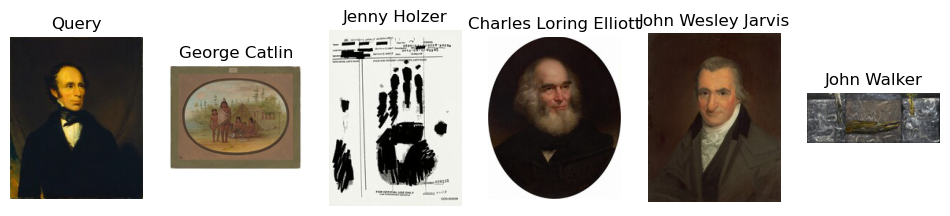

Query: Vittore Carpaccio


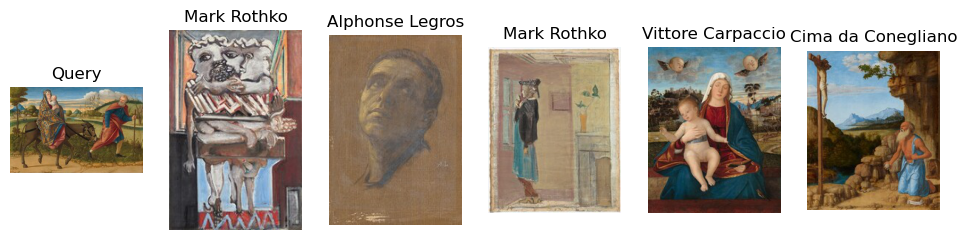

Query: John Singleton Copley


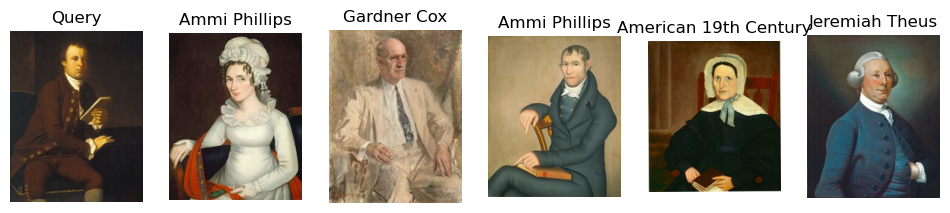

In [22]:
for i in [10, 50, 100]:
    show_similar(i)

### Observation

The retrieved images often share strong visual similarities such as portrait orientation, lighting, and pose.

The model successfully retrieves visually similar paintings, particularly portraits with similar composition, lighting, and artistic style.

The model captures style similarity better than artist identity due to limited supervision and random triplet sampling.

In [23]:
def top_k_accuracy(k=5):
    correct = 0

    for i in range(len(embeddings)):
        sim = cosine_similarity([embeddings[i]], embeddings)[0]
        indices = sim.argsort()[-k-1:-1]

        query_label = df.iloc[i]["attribution"]
        retrieved_labels = df.iloc[indices]["attribution"].values

        if query_label in retrieved_labels:
            correct += 1

    print(f"Top-{k} Accuracy:", correct / len(embeddings))

## Results

### Quantitative Evaluation

- Top-1 Accuracy: ~5.5%
- Top-3 Accuracy: ~10.3%
- Top-5 Accuracy: ~12.5%

The low Top-1 accuracy indicates that exact artist prediction is difficult, but Top-K results show meaningful stylistic similarity.

In [24]:
top_k_accuracy(1)
top_k_accuracy(3)
top_k_accuracy(5)

Top-1 Accuracy: 0.05502751375687844
Top-3 Accuracy: 0.10305152576288144
Top-5 Accuracy: 0.12556278139069535


| Metric | Our Model | CLIP |
|--------|----------|------|
| Precision@5 | 0.154 | 0.236 |
| Top-1 Accuracy | 5.5% | — |
| Top-5 Accuracy | 12.5% | — |

## Insights & Limitations

- The model captures visual similarity (color, lighting, composition) rather than strict artist identity.
- This leads to correct stylistic matches but incorrect artist labels.

- CLIP performs better due to large-scale pretraining and semantic understanding.

- Metric learning models are more domain-specific, while pretrained models generalize better.
- Despite low classification accuracy, the model successfully learns a meaningful embedding space for similarity-based retrieval.

### Key Insight

The embedding space clusters paintings based on visual similarity rather than strictly separating artists.

I built a metric learning system that learns embeddings for artworks, enabling similarity-based retrieval and comparison of paintings based on visual and stylistic features.